In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, recall_score, precision_score, f1_score,\
    confusion_matrix, ConfusionMatrixDisplay

from catboost import CatBoostClassifier
from catboost import utils

In [2]:
train_part1 = pd.read_parquet("ClearData/train_part1.parquet")

In [3]:
x = train_part1.drop(columns="target")
y = train_part1["target"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.1, stratify=y)   

In [5]:
def train_models(model, X_train, X_test, y_train, y_test, sample_weight=None):      # This function training model and output accuracy metrics
    if (sample_weight is None):
        model.fit(X_train, y_train)
    else:
        model.fit(X_train, y_train, sample_weight=sample_weight)
        
    predict_train = model.predict(X_train)
    print(f"Train metrics:")
    print(f"Accuracy: {accuracy_score(y_true=y_train, y_pred=predict_train)}")
    print(f"Precision: {precision_score(y_true=y_train, y_pred=predict_train)}")
    print(f"Recall: {recall_score(y_true=y_train, y_pred=predict_train)}")
    print(f"F1-score: {f1_score(y_true=y_train, y_pred=predict_train)}\n")

    predict_test = model.predict(X_test)
    print(f"Test metrics:")
    print(f"Accuracy: {accuracy_score(y_true=y_test, y_pred=predict_test)}")
    print(f"Precision: {precision_score(y_true=y_test, y_pred=predict_test)}")
    print(f"Recall: {recall_score(y_true=y_test, y_pred=predict_test)}")
    print(f"F1-score: {f1_score(y_true=y_test, y_pred=predict_test)}\n")

    print("Confusion matrix")
    cm = confusion_matrix(y_true=y_test, y_pred=predict_test, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)    
    disp.plot()

In [6]:
CatBoost = CatBoostClassifier(iterations=15, depth=2, auto_class_weights='Balanced', verbose=False)

Train metrics:
Accuracy: 0.860468256573213
Precision: 0.0020958462114748066
Recall: 0.4813370829605011
F1-score: 0.004173520010285557

Test metrics:
Accuracy: 0.8600235511171057
Precision: 0.002035032523065783
Recall: 0.4689298043728424
F1-score: 0.0040524783515611985

Confusion matrix


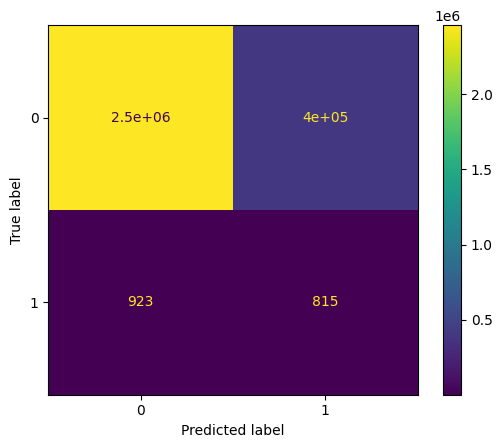

In [7]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [8]:
CatBoost2 = CatBoostClassifier(iterations=15, depth=3, auto_class_weights='Balanced', verbose=False)

Train metrics:
Accuracy: 0.8497860404195656
Precision: 0.0021133251897870937
Recall: 0.5226895053048702
F1-score: 0.004209630107966357

Test metrics:
Accuracy: 0.8494622378453174
Precision: 0.002056390593521673
Recall: 0.5097813578826237
F1-score: 0.004096257426200328

Confusion matrix


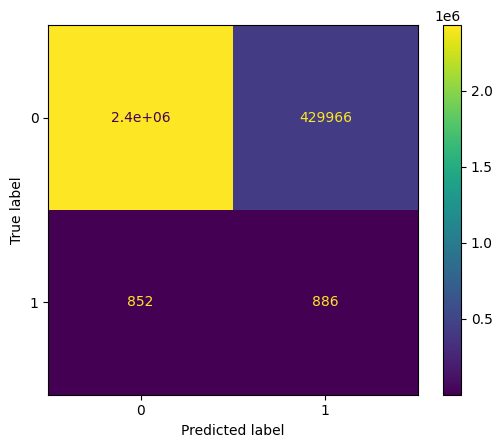

In [9]:
train_models(CatBoost2, X_train, X_test, y_train, y_test)

In [10]:
del CatBoost, CatBoost2
gc.collect()

4183

In [ ]:
CatBoost3 = CatBoostClassifier(iterations=15, depth=4, auto_class_weights='Balanced', verbose=False)

Train metrics:
Accuracy: 0.8654692011805534
Precision: 0.002322878360815437
Recall: 0.5145085005752269
F1-score: 0.004624876550267237

Test metrics:
Accuracy: 0.8649780212868554
Precision: 0.002256611976605766
Recall: 0.5017261219792866
F1-score: 0.004493015730707598

Confusion matrix


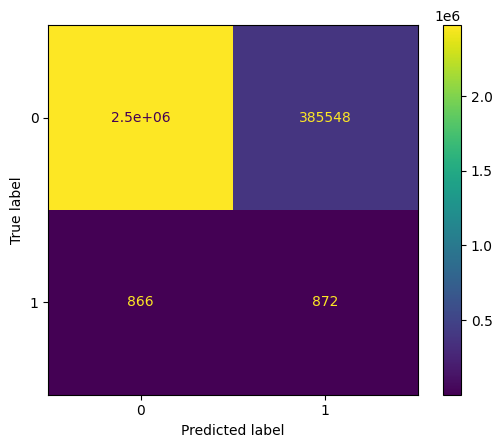

In [16]:
train_models(CatBoost3, X_train, X_test, y_train, y_test)

In [36]:
CatBoost3 = CatBoostClassifier(iterations=50, depth=4, auto_class_weights='Balanced', verbose=False)

Train metrics:
Accuracy: 0.7984935512398428
Precision: 0.001834004935350604
Recall: 0.6087817972644766
F1-score: 0.003656992880669923

Test metrics:
Accuracy: 0.7981330323635677
Precision: 0.0018025779286269096
Recall: 0.5995397008055235
F1-score: 0.0035943490761453536

Confusion matrix


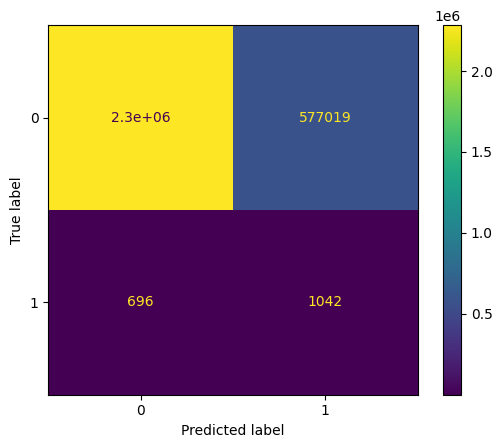

In [37]:
train_models(CatBoost3, X_train, X_test, y_train, y_test)

В результате опытов было выяснено, что для моделей с auto_class_weights='Balanced' глубина 4 давала наилучшие результаты при числе итераций 15

Попробуем настроить веса меток самостоятельно

In [87]:
weights = {0: 1, 1: 100}
CatBoost4 = CatBoostClassifier(iterations=15, depth=5, class_weights=weights, verbose=False)

Train metrics:
Accuracy: 0.9974338749625632
Precision: 0.019377703256292515
Recall: 0.0650006391409945
F1-score: 0.029855127772314288

Test metrics:
Accuracy: 0.9974118230800948
Precision: 0.020956565827277337
Recall: 0.0713463751438435
F1-score: 0.03239712606139778

Confusion matrix


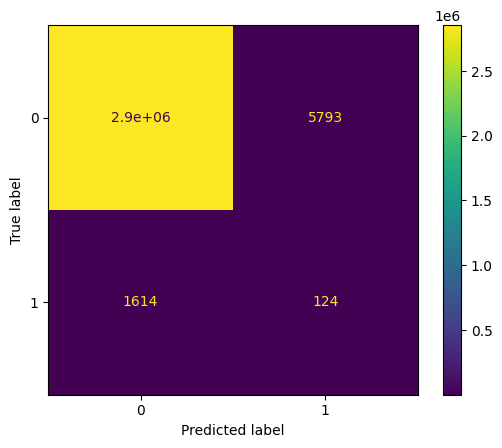

In [88]:
train_models(CatBoost4, X_train, X_test, y_train, y_test)

In [60]:
weights = {0: 1, 1: 100}
CatBoost4 = CatBoostClassifier(iterations=100, depth=5, class_weights=weights, verbose=False)

Train metrics:
Accuracy: 0.994507416972975
Precision: 0.018623797755044264
Recall: 0.1555669180621245
F1-score: 0.03326522663131496

Test metrics:
Accuracy: 0.9944892482511374
Precision: 0.017666872894754933
Recall: 0.1478711162255466
F1-score: 0.031562787841572

Confusion matrix


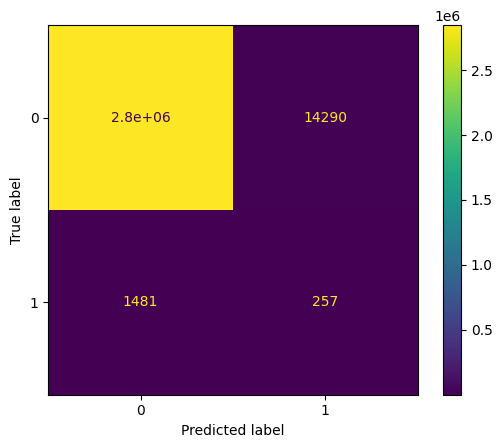

In [61]:
train_models(CatBoost4, X_train, X_test, y_train, y_test)

In [56]:
weights = {0: 1, 1: 1000}
CatBoost4 = CatBoostClassifier(iterations=100, depth=5, class_weights=weights, verbose=False)

Train metrics:
Accuracy: 0.9250565308474281
Precision: 0.0039000779911955454
Recall: 0.4810175124632494
F1-score: 0.0077374211646124525

Test metrics:
Accuracy: 0.9249383268224162
Precision: 0.003717264317057492
Recall: 0.45914844649021863
F1-score: 0.007374822098589727

Confusion matrix


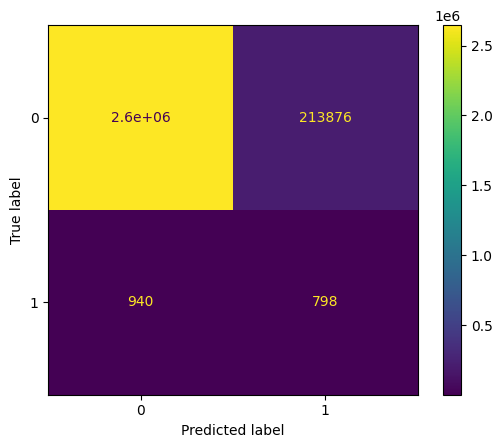

In [57]:
train_models(CatBoost4, X_train, X_test, y_train, y_test)

In [62]:
weights = {0: 1, 1: 1000}
CatBoost4 = CatBoostClassifier(iterations=200, depth=5, class_weights=weights, verbose=False)

Train metrics:
Accuracy: 0.9281917497769709
Precision: 0.004169099993511128
Recall: 0.49277770676211174
F1-score: 0.008268247249547713

Test metrics:
Accuracy: 0.9280282753174509
Precision: 0.0038769670263468572
Recall: 0.45914844649021863
F1-score: 0.007689009437825494

Confusion matrix


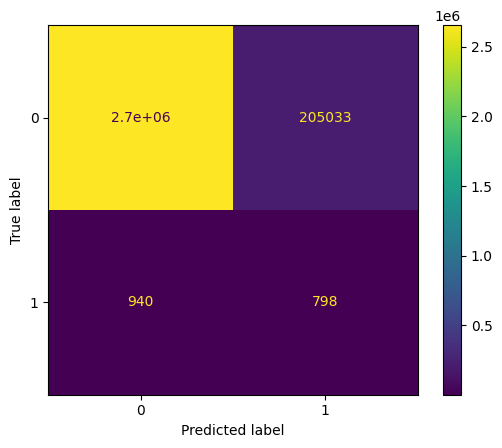

In [63]:
train_models(CatBoost4, X_train, X_test, y_train, y_test)

In [64]:
weights = {0: 1, 1: 1000}
CatBoost4 = CatBoostClassifier(iterations=20, depth=4, class_weights=weights, verbose=False)

Train metrics:
Accuracy: 0.919417811279955
Precision: 0.0033077643486756885
Recall: 0.43838680812987346
F1-score: 0.006565986295573727

Test metrics:
Accuracy: 0.9193154102576646
Precision: 0.0032126320170646687
Recall: 0.42635212888377444
F1-score: 0.006377210723352985

Confusion matrix


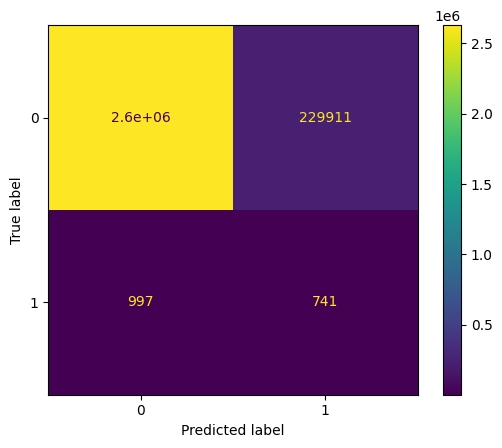

In [65]:
train_models(CatBoost4, X_train, X_test, y_train, y_test)

In [83]:
weights = {0: 1, 1: 800}
CatBoost4 = CatBoostClassifier(iterations=200, depth=4, class_weights=weights, verbose=False)

Train metrics:
Accuracy: 0.9400831254459513
Precision: 0.00469490570307834
Recall: 0.4627380800204525
F1-score: 0.009295499963729576

Test metrics:
Accuracy: 0.9399254331099355
Precision: 0.004385735003756705
Recall: 0.4332566168009206
F1-score: 0.008683568681492927

Confusion matrix


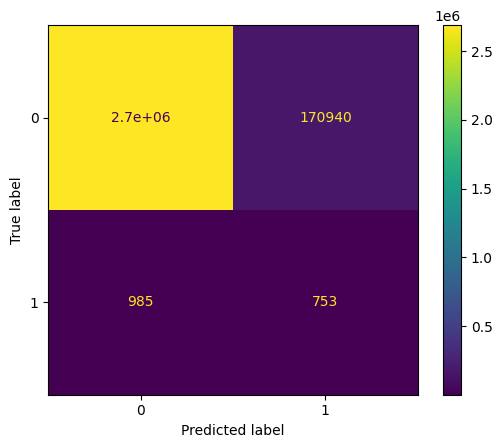

In [84]:
train_models(CatBoost4, X_train, X_test, y_train, y_test)

In [79]:
weights = {0: 1, 1: 500}
CatBoost4 = CatBoostClassifier(iterations=20, depth=4, class_weights=weights, verbose=False)

Train metrics:
Accuracy: 0.9638817949511767
Precision: 0.005574337290651525
Recall: 0.32954109676594656
F1-score: 0.01096322662473594

Test metrics:
Accuracy: 0.9637623783134046
Precision: 0.005355427706576892
Recall: 0.3176064441887227
F1-score: 0.01053324555628703

Confusion matrix


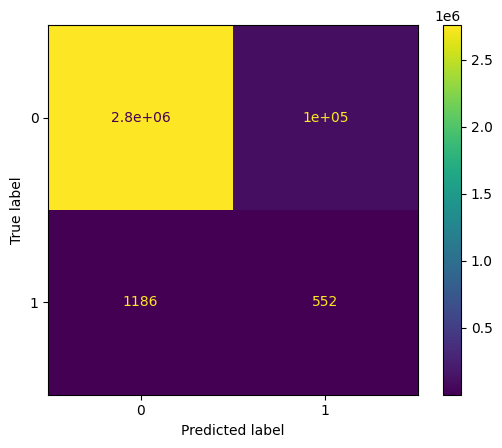

In [80]:
train_models(CatBoost4, X_train, X_test, y_train, y_test)

In [81]:
weights = {0: 1, 1: 500}
CatBoost4 = CatBoostClassifier(iterations=200, depth=4, class_weights=weights, verbose=False)

Train metrics:
Accuracy: 0.9630038497893405
Precision: 0.006545321295670359
Recall: 0.39729004218330566
F1-score: 0.012878470826617163

Test metrics:
Accuracy: 0.9628989538272312
Precision: 0.005960264900662252
Recall: 0.3624856156501726
F1-score: 0.01172769411195294

Confusion matrix


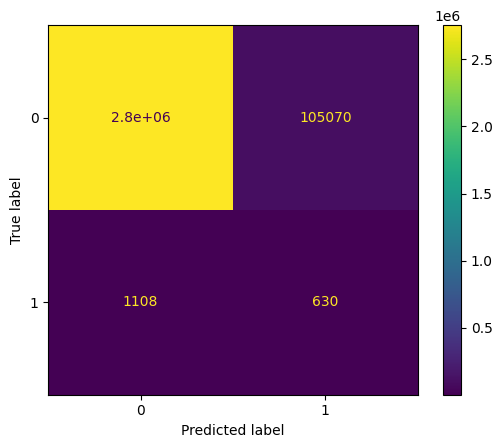

In [82]:
train_models(CatBoost4, X_train, X_test, y_train, y_test)